# Method A (Baseline) — 관계별 가중치 조절 (Relation Gating)

> **static relation-gating**: 사람이 메타패스를 고정하고 AI는 관계별 스칼라 α_r만 조절하는 **baseline(대조군)**.
> 동적 메타패스 탐색(Method B)은 [`methodB_metapath_search.ipynb`](methodB_metapath_search.ipynb) 참조.
> 설계 문서: [`docs/methodology_baseline_relation_gating.md`](../../docs/methodology_baseline_relation_gating.md)

| 실험 | 핵심 변경점 | 목적 |
|---|---|---|
| **exp01** Baseline | 기본 세팅 | 비교 기준점 (test PR-AUC=0.4844) |
| **exp02** α 튜닝 | lr_alpha 0.02 / temperature 0.5 | α_r 균등 문제 해결 |
| **exp03** 보완재 엣지 | include_complement_edges=true | 동반구매 관계 Ablation |
| **exp06** 동반구매 Lift | co_offline+co_quick, Lift 가중치 | Lift 신호 기여 측정 |
| **exp07** 동반구매 Binary | co_offline+co_quick, 엣지 존재만 | Lift 값 자체 기여 검증 |

> 셀 순서대로 실행하면 전체 실험 순차 학습 → 최종 비교표 출력.  
> 특정 실험만 재실행: 해당 섹션 셀만 실행 (`force=True` 주석 해제).  
> 랜덤 기준선: PR-AUC=0.236 (양성 23.6%) / AUC-ROC=0.500

## 0. 환경 설정 (공통)

In [1]:
import os, sys
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib

# __vsc_ipynb_file__ 우선 (VS Code 환경), 없으면 CWD에서 상위 탐색
_nb_file = globals().get('__vsc_ipynb_file__', None)
_anchor  = Path(_nb_file).resolve().parent if _nb_file else Path.cwd()
ROOT = None
for _p in [_anchor] + list(_anchor.parents):
    if (_p / "CLAUDE.md").exists():
        ROOT = str(_p)
        break
if ROOT is None:
    ROOT = str(_anchor)

if ROOT not in sys.path:
    sys.path.insert(0, ROOT)
os.chdir(ROOT)

matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False

from experiments.exp_utils import (
    run_experiment, load_experiment, compare_experiments,
    plot_alpha_heatmap, plot_training_curve, print_metrics_table, print_recommendations
)

CFG = {
    'exp01': 'experiments/configs/exp01_baseline.yaml',
    'exp02': 'experiments/configs/exp02_alpha_tuning.yaml',
    'exp03': 'experiments/configs/exp03_complement_edges.yaml',
    'exp06': 'experiments/configs/exp06_both_copurchase.yaml',
    'exp07': 'experiments/configs/exp07_copurchase_binary.yaml',
}

def save_fig(fig, exp_name, filename):
    path = f'experiments/results/{exp_name}/{filename}'
    os.makedirs(os.path.dirname(path), exist_ok=True)
    fig.savefig(path, dpi=120, bbox_inches='tight')
    plt.show()

print('ROOT:', ROOT)
assert os.path.exists('experiments/configs'), "경로 오류: experiments/configs 없음"

ROOT: C:\Users\송정현\Documents\Projects\박재홍교수님세미나\Projects\20기\7eleven_npd_framework


---
## 1. exp01 — Baseline

| 항목 | 값 |
|---|---|
| 핵심 세팅 | hidden=128, layers=2, heads=4, lr_w=0.005, lr_α=0.005, temperature=1.0, complement=False |
| 기존 결과 | test PR-AUC=0.4844, AUC-ROC=0.7789 |
| 문제점 | α_r 균등(≈1/8=0.125) → DiffMG 관계 게이팅 미분화 |

In [2]:
r01 = run_experiment(CFG['exp01'], 'exp01_baseline')
# 재학습 강제: r01 = run_experiment(CFG['exp01'], 'exp01_baseline', force=True)

c:\Users\송정현\Documents\Projects\박재홍교수님세미나\Projects\20기\7eleven_npd_framework\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[001] loss_w=1.0841 val_pr_auc=0.3873 val_auc=0.6952
[010] loss_w=0.9417 val_pr_auc=0.4773 val_auc=0.7243
[020] loss_w=0.7875 val_pr_auc=0.4865 val_auc=0.7427
[030] loss_w=0.5194 val_pr_auc=0.4682 val_auc=0.7362
[040] loss_w=0.3655 val_pr_auc=0.4729 val_auc=0.7348
early stop @ 47 (best pr_auc=0.5043)
TEST: {'pr_auc': 0.5265, 'auc_roc': 0.7725, 'threshold': 0.3889, 'f1': 0.5333}
[exp01_baseline] 완료 → experiments/results\exp01_baseline


In [3]:
print_metrics_table(r01)


split      PR-AUC   AUC-ROC   F1@best  threshold
------------------------------------------------
train      0.5953    0.8169    0.5711     0.6149
val        0.5043    0.7456    0.5000     0.3260
test       0.5265    0.7725    0.5333     0.3889

[random]   0.2360


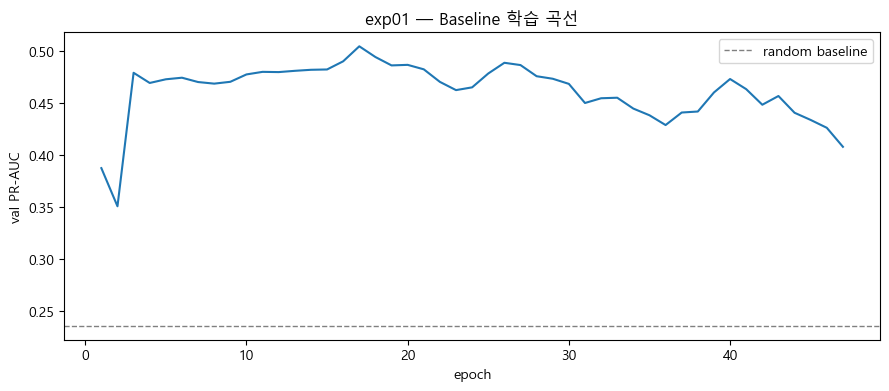

In [4]:
fig, ax = plt.subplots(figsize=(9, 4))
plot_training_curve(r01.get('history', []), ax=ax)
ax.set_title('exp01 — Baseline 학습 곡선')
save_fig(fig, 'exp01_baseline', 'training_curve.png')

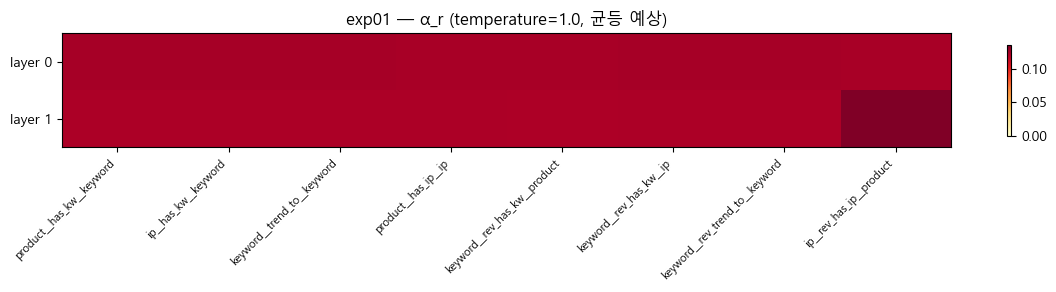

In [5]:
fig, ax = plt.subplots(figsize=(12, 3))
plot_alpha_heatmap('exp01_baseline', ax=ax)
ax.set_title('exp01 — α_r (temperature=1.0, 균등 예상)')
save_fig(fig, 'exp01_baseline', 'alpha_heatmap.png')

In [6]:
print_recommendations(r01)

  마라 → 도쿠시(0.0331), 향라(0.0327), 탄탄(0.0327), 샹궈(0.0260), 박은영(0.0218), 중독성(0.0168), 떠먹음(0.0150), 파티팩(0.0141), 얼얼함(0.0141), 특식(0.0133)
  로제 → 로제와인(0.0216), 중독성(0.0160), 로트캡션(0.0150), 뽀므리(0.0114), 대왕(0.0095), 납작(0.0080), 늘어남(0.0076), 앙리(0.0069), 원데이(0.0066), 바리스타룰스(0.0066)
  흑임자 → 시루떡(0.0298), 비비빅(0.0192), 공룡(0.0137), 롱롱이(0.0111), 작은별(0.0105), 컵케익(0.0103), 알(0.0069), 프라임(0.0068), 적음(0.0047), 빵또아(0.0037)
  단백질 → 베노프(0.0080), 동물(0.0079), 밸런스밀(0.0079), 엽떡(0.0078), 이지프로틴(0.0078), 아르기닌(0.0078), 플러스(0.0078), 헬스(0.0078), 편함(0.0078), 동의(0.0073)
  위스키 → 빔산토리(0.0052), 산토리(0.0052), 티처스위스키(0.0052), 블랙서클(0.0051), 컬렉션(0.0050), 키노(0.0049), 블론드(0.0049), 노마드리저브(0.0049), 키싱(0.0049), 더글렌드로낙(0.0049)
  딸기 → 분홍(0.0037), 니타(0.0037), 키티(0.0037), 돌직구(0.0032), 트롤(0.0032), 4D(0.0032), 고칸(0.0031), 픽업(0.0028), 포장(0.0028), 헬로키티(0.0025)


---
## 2. exp02 — DiffMG α 튜닝

| 항목 | 값 |
|---|---|
| 변경점 | lr_alpha 0.005 → **0.02** / temperature 1.0 → **0.5** |
| 목적 | α_r 균등 문제 해결 — 관계 게이팅 실질 분화 유도 |
| 가설 | α_r 분산 증가 → 유의미한 관계에 가중치 집중 → PR-AUC 개선 |

In [7]:
r02 = run_experiment(CFG['exp02'], 'exp02_alpha_tuning')
# 재학습 강제: r02 = run_experiment(CFG['exp02'], 'exp02_alpha_tuning', force=True)

[001] loss_w=1.0763 val_pr_auc=0.4094 val_auc=0.6563
[010] loss_w=0.9573 val_pr_auc=0.4714 val_auc=0.7218
[020] loss_w=0.8174 val_pr_auc=0.4819 val_auc=0.7317
[030] loss_w=0.5504 val_pr_auc=0.4732 val_auc=0.7406
[040] loss_w=0.3987 val_pr_auc=0.4671 val_auc=0.7358
early stop @ 46 (best pr_auc=0.4962)
TEST: {'pr_auc': 0.5275, 'auc_roc': 0.7699, 'threshold': 0.4001, 'f1': 0.5316}
[exp02_alpha_tuning] 완료 → experiments/results\exp02_alpha_tuning


In [8]:
print_metrics_table(r02)


split      PR-AUC   AUC-ROC   F1@best  threshold
------------------------------------------------
train      0.5728    0.8030    0.5646     0.4013
val        0.4962    0.7400    0.5116     0.5772
test       0.5275    0.7699    0.5316     0.4001

[random]   0.2360


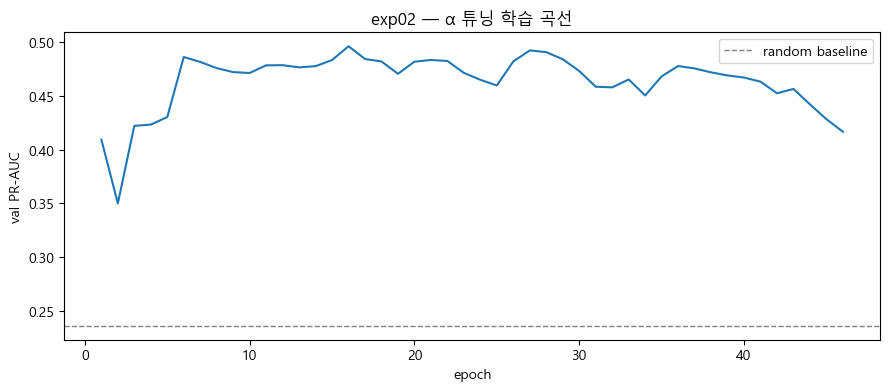

In [9]:
fig, ax = plt.subplots(figsize=(9, 4))
plot_training_curve(r02.get('history', []), ax=ax)
ax.set_title('exp02 — α 튜닝 학습 곡선')
save_fig(fig, 'exp02_alpha_tuning', 'training_curve.png')

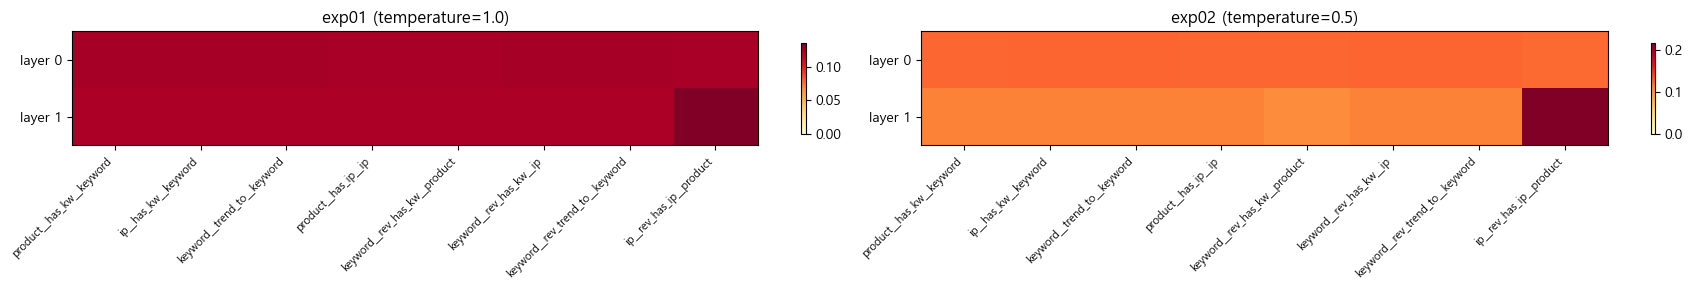

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(18, 3))
plot_alpha_heatmap('exp01_baseline', ax=axes[0])
axes[0].set_title('exp01 (temperature=1.0)')
plot_alpha_heatmap('exp02_alpha_tuning', ax=axes[1])
axes[1].set_title('exp02 (temperature=0.5)')
save_fig(fig, 'exp02_alpha_tuning', 'alpha_heatmap_compare.png')

In [ ]:
print_recommendations(r02)

---
## 3. exp03 — 보완재 엣지 Ablation

| 항목 | 값 |
|---|---|
| 변경점 | include_complement_edges: false → **true** (968쌍, Lift≥3.0) |
| 기반 | exp02 (α튜닝) 위에 보완재 엣지만 추가 |
| 주의 | complement 엣지는 세븐일레븐 POS 기반 — CU/GS25 미적용 |

In [11]:
import pandas as pd
cp = pd.read_csv('data/processed/complement_lift_pairs.csv')
print(f'보완재 쌍: {len(cp):,}행')
print(f'Lift 분포:\n{cp["향상도(Lift)"].describe().round(1)}')
display(cp.head(5))

보완재 쌍: 968행
Lift 분포:
count     968.0
mean      132.5
std       351.3
min         3.0
25%         5.8
50%        18.5
75%       105.5
max      5614.0
Name: 향상도(Lift), dtype: float64


,상품명_A,상품명_B,상품코드_A,상품코드_B,동반구매빈도(Support),향상도(Lift)
0,APP예약)렌틸콩유부초밥&에그샐러드,APP예약)홀그레인머스타드닭가슴살김밥,123618,123619,111,5613.9909
1,CJ)비비고붕어빵젤리포도40g,CJ)비비고왕교자젤리복숭아40g,129947,129948,107,3223.8042
2,에이스)와사비치킨아몬드80g,에이스)매운치킨아몬드80g,125634,125635,120,2776.9832
3,CJ)작은햇반흑미밥130g*3입,CJ)작은햇반발아현미밥130g*3입,140305,140307,209,2652.4273
4,CJ)더건강한저당닭가슴살숯불치킨맛120g,CJ)더건강한저당닭가슴살데리야끼맛120g,132888,132890,113,2634.0383


In [12]:
r03 = run_experiment(CFG['exp03'], 'exp03_complement_edges')
# 재학습 강제: r03 = run_experiment(CFG['exp03'], 'exp03_complement_edges', force=True)

[001] loss_w=1.1109 val_pr_auc=0.3475 val_auc=0.6293
[010] loss_w=0.9731 val_pr_auc=0.4766 val_auc=0.7239
[020] loss_w=0.9246 val_pr_auc=0.4833 val_auc=0.7295
[030] loss_w=0.7664 val_pr_auc=0.5046 val_auc=0.7531
[040] loss_w=0.5404 val_pr_auc=0.5105 val_auc=0.7620
[050] loss_w=0.4684 val_pr_auc=0.4460 val_auc=0.7366
[060] loss_w=0.2925 val_pr_auc=0.4275 val_auc=0.7293
early stop @ 69 (best pr_auc=0.5138)
TEST: {'pr_auc': 0.5464, 'auc_roc': 0.7883, 'threshold': 0.7097, 'f1': 0.5529}
[exp03_complement_edges] 완료 → experiments/results\exp03_complement_edges


In [13]:
print_metrics_table(r03)


split      PR-AUC   AUC-ROC   F1@best  threshold
------------------------------------------------
train      0.7510    0.9203    0.7247     0.6482
val        0.5138    0.7663    0.5308     0.5710
test       0.5464    0.7883    0.5529     0.7097

[random]   0.2360


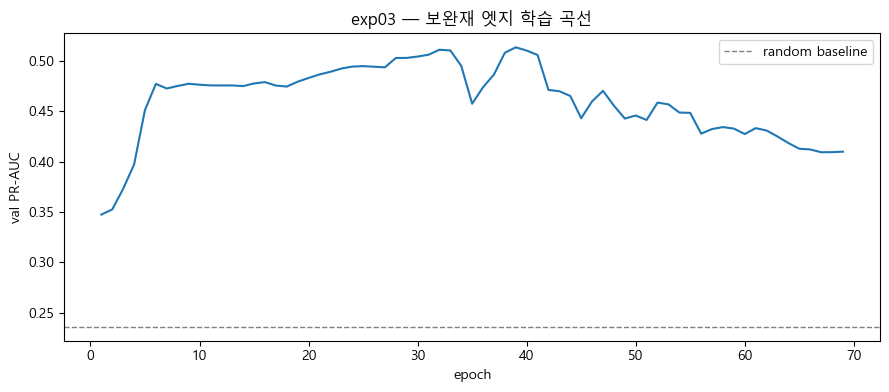

In [14]:
fig, ax = plt.subplots(figsize=(9, 4))
plot_training_curve(r03.get('history', []), ax=ax)
ax.set_title('exp03 — 보완재 엣지 학습 곡선')
save_fig(fig, 'exp03_complement_edges', 'training_curve.png')

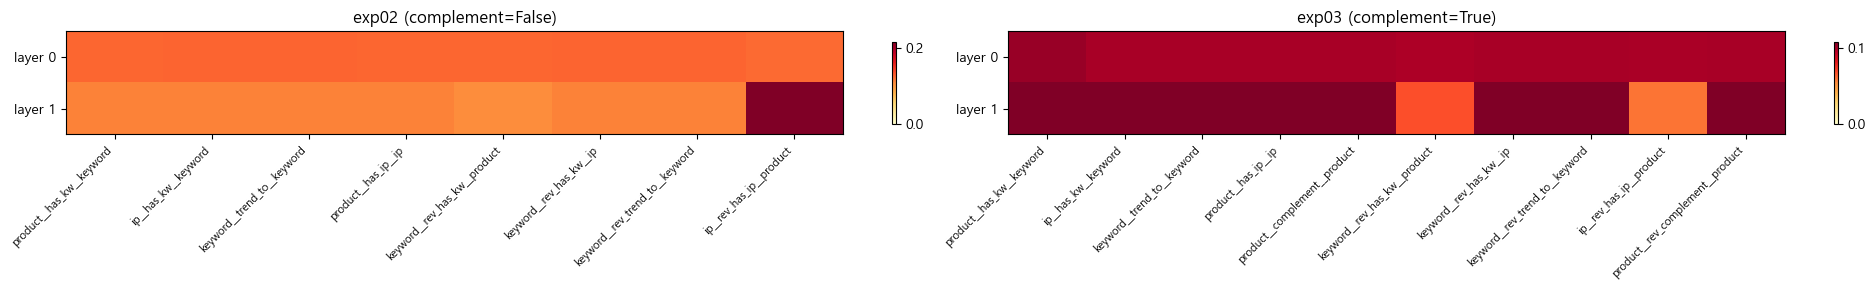

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(20, 3))
plot_alpha_heatmap('exp02_alpha_tuning', ax=axes[0])
axes[0].set_title('exp02 (complement=False)')
plot_alpha_heatmap('exp03_complement_edges', ax=axes[1])
axes[1].set_title('exp03 (complement=True)')
save_fig(fig, 'exp03_complement_edges', 'alpha_heatmap_compare.png')

In [16]:
print('=== exp03 추천 ===')
print_recommendations(r03)
print('\n=== exp02 추천 (비교) ===')
print_recommendations(r02)

=== exp03 추천 ===
  마라 → 도쿠시(0.0370), 향라(0.0354), 탄탄(0.0328), 박은영(0.0212), 샹궈(0.0190), 중독성(0.0189), 짜파게티(0.0127), 누들핏(0.0109), 적음(0.0109), 피(0.0100)
  로제 → 중독성(0.0182), 로제와인(0.0171), 로트캡션(0.0151), 늘어남(0.0151), 대왕(0.0106), 마카로니(0.0101), 납작(0.0065), 앙리(0.0049), 파마산(0.0046), 럭히밥(0.0046)
  흑임자 → 롱롱이(0.0202), 시루떡(0.0190), 공룡(0.0164), 컵케익(0.0123), 비비빅(0.0095), 알(0.0081), 파운드(0.0030), 마카롱(0.0021), 찰떡(0.0020), 드레싱(0.0018)
  단백질 → 이지프로틴(0.0095), 아르기닌(0.0095), 베노프(0.0092), 밸런스밀(0.0090), 동물(0.0089), 엽떡(0.0089), 헬스(0.0083), 편함(0.0082), 플러스(0.0074), 프로틴바(0.0056)
  위스키 → 빔산토리(0.0058), 산토리(0.0058), 티처스위스키(0.0058), 블랙서클(0.0058), 컬렉션(0.0056), 더글렌드로낙(0.0054), 예술(0.0054), 노마드리저브(0.0045), 트레이스(0.0044), 클레이모어(0.0042)
  딸기 → 분홍(0.0043), 돌직구(0.0042), 트롤(0.0042), 키티(0.0041), 고칸(0.0040), 니타(0.0040), 픽업(0.0038), 포장(0.0038), 빅파이(0.0037), 4D(0.0037)

=== exp02 추천 (비교) ===
  마라 → 도쿠시(0.0321), 탄탄(0.0313), 향라(0.0313), 샹궈(0.0260), 박은영(0.0211), 떠먹음(0.0168), 파티팩(0.0164), 얼얼함(0.0164), 특식(0.0160), 중독성(0.0156)
  로제 → 로제와인(

---
## 4. exp06 — 동반구매 엣지 Lift × α_r

| 항목 | 값 |
|---|---|
| 변경점 | co_offline + co_quick 엣지 추가, use_lift_weights=true |
| 데이터 | offline_commerce (968쌍) / quick_commerce (761쌍) |
| 목적 | Lift 가중 동반구매 엣지가 NPD 예측에 기여하는지 측정 |

In [17]:
r06 = run_experiment(CFG['exp06'], 'exp06_both_copurchase')
# 재학습 강제: r06 = run_experiment(CFG['exp06'], 'exp06_both_copurchase', force=True)

[001] loss_w=1.0584 val_pr_auc=0.4630 val_auc=0.6615
[010] loss_w=0.9628 val_pr_auc=0.4880 val_auc=0.7392
[020] loss_w=0.9087 val_pr_auc=0.4931 val_auc=0.7405
[030] loss_w=0.5674 val_pr_auc=0.6158 val_auc=0.8053
[040] loss_w=0.3846 val_pr_auc=0.6224 val_auc=0.8025
[050] loss_w=0.2861 val_pr_auc=0.5812 val_auc=0.7747
[060] loss_w=0.2702 val_pr_auc=0.5471 val_auc=0.7684
early stop @ 62 (best pr_auc=0.6396)
TEST: {'pr_auc': 0.6726, 'auc_roc': 0.8318, 'threshold': 0.8609, 'f1': 0.6129}
[exp06_both_copurchase] 완료 → experiments/results\exp06_both_copurchase


In [18]:
print_metrics_table(r06)


split      PR-AUC   AUC-ROC   F1@best  threshold
------------------------------------------------
train      0.7743    0.9319    0.7539     0.6633
val        0.6396    0.8123    0.6154     0.7508
test       0.6598    0.8294    0.6059     0.7804

[random]   0.2360


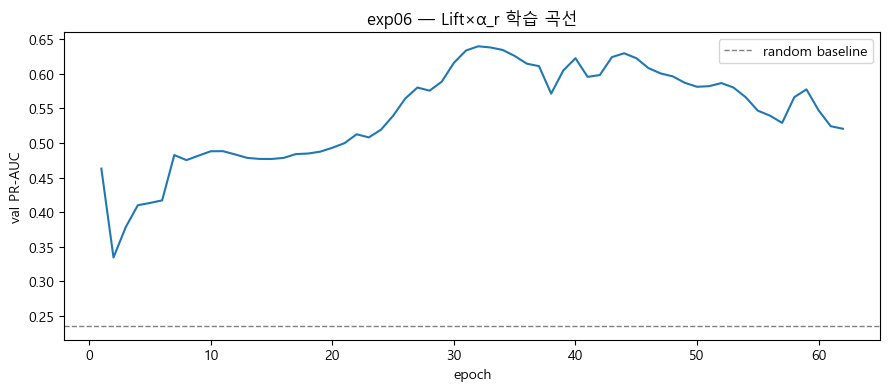

In [19]:
fig, ax = plt.subplots(figsize=(9, 4))
plot_training_curve(r06.get('history', []), ax=ax)
ax.set_title('exp06 — Lift×α_r 학습 곡선')
save_fig(fig, 'exp06_both_copurchase', 'training_curve.png')

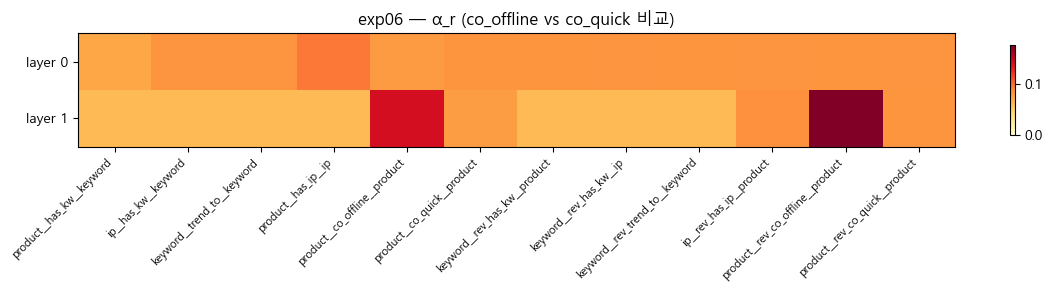

In [20]:
fig, ax = plt.subplots(figsize=(12, 3))
plot_alpha_heatmap('exp06_both_copurchase', ax=ax)
ax.set_title('exp06 — α_r (co_offline vs co_quick 비교)')
save_fig(fig, 'exp06_both_copurchase', 'alpha_heatmap.png')

In [21]:
print_recommendations(r06)

  마라 → 도쿠시(0.0391), 향라(0.0390), 탄탄(0.0345), 중독성(0.0164), 샹궈(0.0149), 피(0.0132), 짜파게티(0.0127), 누들핏(0.0115), 적음(0.0115), 마라탕(0.0076)
  로제 → 로제와인(0.0193), 원데이(0.0160), 바리스타룰스(0.0160), 중독성(0.0158), 늘어남(0.0137), 앙리(0.0134), 로트캡션(0.0107), 마카로니(0.0091), 앙리마티스(0.0089), 대왕(0.0088)
  흑임자 → 공룡(0.0181), 롱롱이(0.0169), 시루떡(0.0139), 컵케익(0.0135), 알(0.0090), 비비빅(0.0070), 마카롱(0.0022), 묵직함(0.0017), 찰떡(0.0014), 할매니얼(0.0008)
  단백질 → 헬스(0.0096), 베노프(0.0095), 엽떡(0.0093), 동물(0.0091), 이지프로틴(0.0079), 아르기닌(0.0079), 밸런스밀(0.0068), 편함(0.0056), 소이조이(0.0048), 프로틴바(0.0047)
  위스키 → 블랙서클(0.0062), 빔산토리(0.0055), 산토리(0.0055), 티처스위스키(0.0055), 컬렉션(0.0048), 예술(0.0046), 더글렌드로낙(0.0043), 메이커스마크(0.0032), 12년(0.0024), 스트레이트(0.0023)
  딸기 → 분홍(0.0043), 트롤(0.0042), 키티(0.0040), 돌직구(0.0038), 니타(0.0038), 4D(0.0038), 고칸(0.0038), 몽쉘(0.0036), 쿠냥이(0.0034), 빅파이(0.0034)


---
## 5. exp07 — 동반구매 엣지 Binary × α_r

| 항목 | 값 |
|---|---|
| 변경점 | exp06 동일 구조, use_lift_weights=**false**만 다름 |
| 목적 | Lift 값 자체의 신호 기여 검증 — 엣지 존재만으로도 충분한지 비교 |

In [22]:
r07 = run_experiment(CFG['exp07'], 'exp07_copurchase_binary')
# 재학습 강제: r07 = run_experiment(CFG['exp07'], 'exp07_copurchase_binary', force=True)

[001] loss_w=1.0617 val_pr_auc=0.4506 val_auc=0.6552
[010] loss_w=0.8334 val_pr_auc=0.6504 val_auc=0.7962
[020] loss_w=0.5432 val_pr_auc=0.6557 val_auc=0.8129
[030] loss_w=0.3809 val_pr_auc=0.6161 val_auc=0.7879
[040] loss_w=0.2393 val_pr_auc=0.5519 val_auc=0.7712
early stop @ 45 (best pr_auc=0.6693)
TEST: {'pr_auc': 0.6877, 'auc_roc': 0.8424, 'threshold': 0.6166, 'f1': 0.6205}
[exp07_copurchase_binary] 완료 → experiments/results\exp07_copurchase_binary


In [23]:
print_metrics_table(r07)


split      PR-AUC   AUC-ROC   F1@best  threshold
------------------------------------------------
train      0.7395    0.9054    0.6946     0.4527
val        0.6693    0.8156    0.6237     0.5652
test       0.6877    0.8424    0.6205     0.6166

[random]   0.2360


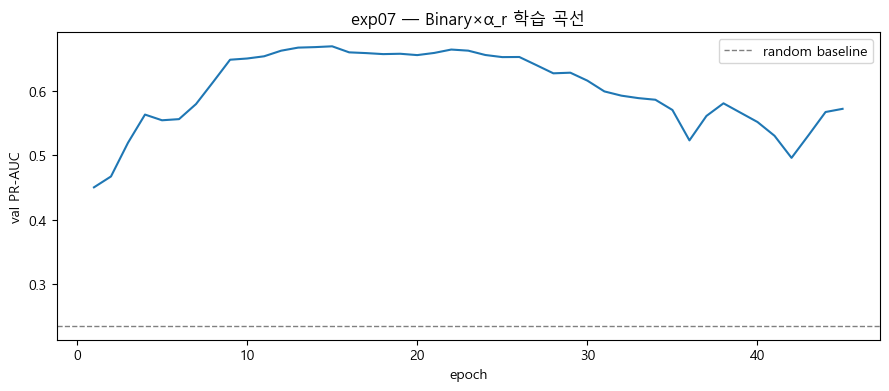

In [24]:
fig, ax = plt.subplots(figsize=(9, 4))
plot_training_curve(r07.get('history', []), ax=ax)
ax.set_title('exp07 — Binary×α_r 학습 곡선')
save_fig(fig, 'exp07_copurchase_binary', 'training_curve.png')

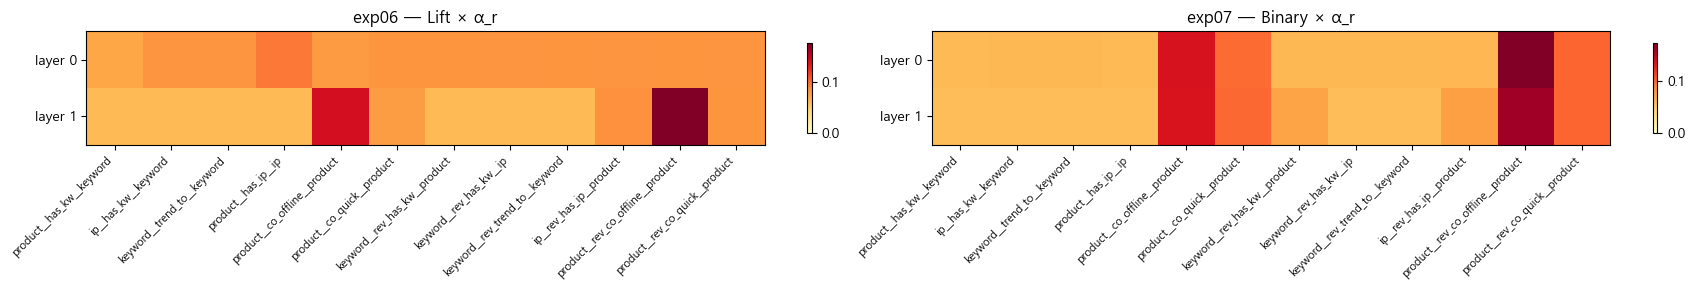

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(18, 3))
plot_alpha_heatmap('exp06_both_copurchase', ax=axes[0])
axes[0].set_title('exp06 — Lift × α_r')
plot_alpha_heatmap('exp07_copurchase_binary', ax=axes[1])
axes[1].set_title('exp07 — Binary × α_r')
save_fig(fig, 'exp07_copurchase_binary', 'alpha_heatmap_compare.png')

In [26]:
print_recommendations(r07)

  마라 → 도쿠시(0.0406), 향라(0.0394), 탄탄(0.0385), 샹궈(0.0188), 중독성(0.0139), 피(0.0136), 짜파게티(0.0132), 적음(0.0129), 누들핏(0.0128), 곤약(0.0081)
  로제 → 로제와인(0.0219), 바리스타룰스(0.0190), 원데이(0.0189), 중독성(0.0133), 납작(0.0081), 늘어남(0.0074), 미정당(0.0057), 로트캡션(0.0055), 뽀므리(0.0055), 당면(0.0053)
  흑임자 → 공룡(0.0185), 컵케익(0.0138), 시루떡(0.0115), 롱롱이(0.0108), 알(0.0092), 비비빅(0.0076), 작은별(0.0073), 할매니얼(0.0031), 프라임(0.0029), 빵또아(0.0023)
  단백질 → 헬스(0.0098), 엽떡(0.0096), 동물(0.0095), 베노프(0.0094), 소이조이(0.0061), 테이크핏(0.0057), 밸런스밀(0.0047), 이지프로틴(0.0043), 아르기닌(0.0043), 프로틴바(0.0042)
  위스키 → 블랙서클(0.0062), 빔산토리(0.0052), 산토리(0.0052), 티처스위스키(0.0052), 티처스하이랜드(0.0046), 컬렉션(0.0030), 블론드(0.0020), 스카치(0.0019), 예술(0.0019), 키싱(0.0018)
  딸기 → 분홍(0.0042), 트롤(0.0042), 키티(0.0040), 4D(0.0040), 돌직구(0.0038), 니타(0.0038), 고칸(0.0037), 픽업(0.0035), 포장(0.0035), 몽쉘(0.0032)


---
## 6. 최종 비교

In [27]:
df = compare_experiments([
    'exp01_baseline',
    'exp02_alpha_tuning',
    'exp03_complement_edges',
    'exp06_both_copurchase',
    'exp07_copurchase_binary',
])
display(df[['exp', 'val_pr_auc', 'val_auc_roc', 'test_pr_auc', 'test_auc_roc', 'test_f1']])

,exp,val_pr_auc,val_auc_roc,test_pr_auc,test_auc_roc,test_f1
0,exp01_baseline,0.5043,0.7456,0.5265,0.7725,0.5333
1,exp02_alpha_tuning,0.4962,0.7400,0.5275,0.7699,0.5316
2,exp03_complement_edges,0.5138,0.7663,0.5464,0.7883,0.5529
3,exp06_both_copurchase,0.6396,0.8123,0.6598,0.8294,0.6059
4,exp07_copurchase_binary,0.6693,0.8156,0.6877,0.8424,0.6205
5,[random baseline],NaN,NaN,0.2360,NaN,NaN


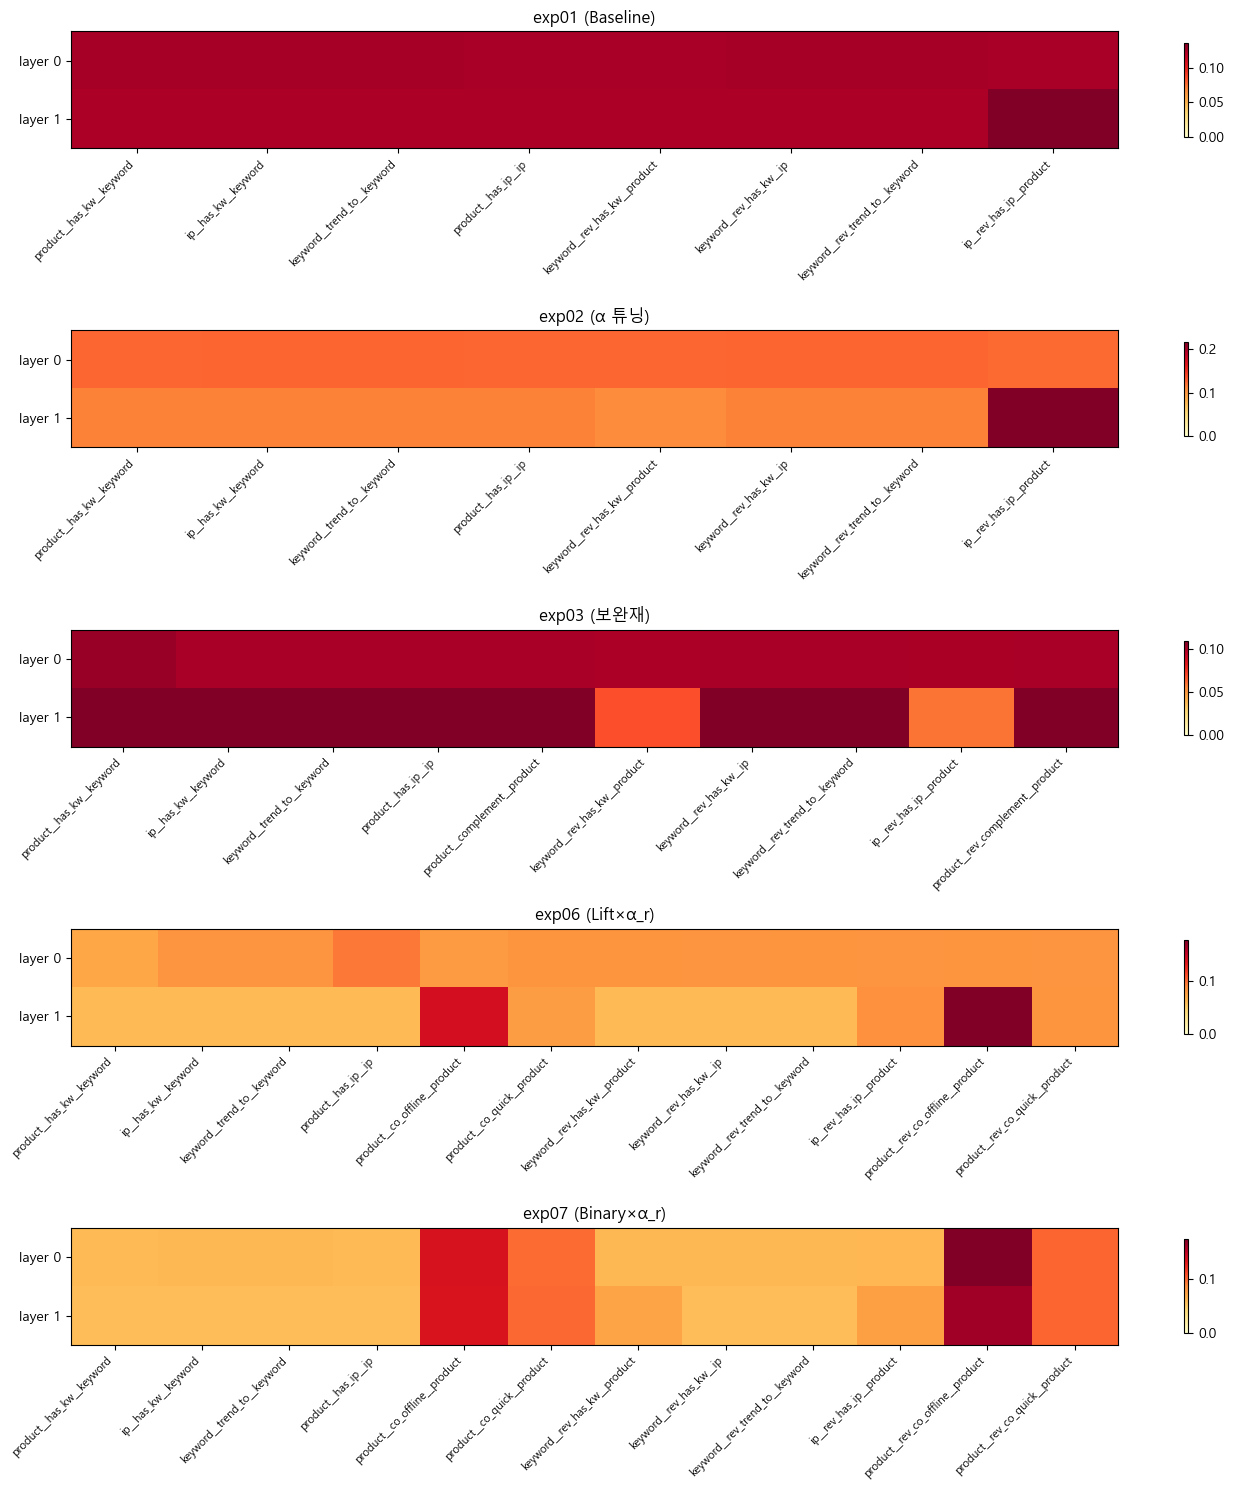

In [28]:
# 전체 α_r 패턴 비교
exp_list = [
    ('exp01_baseline',       'exp01 (Baseline)'),
    ('exp02_alpha_tuning',   'exp02 (α 튜닝)'),
    ('exp03_complement_edges', 'exp03 (보완재)'),
    ('exp06_both_copurchase',  'exp06 (Lift×α_r)'),
    ('exp07_copurchase_binary', 'exp07 (Binary×α_r)'),
]
fig, axes = plt.subplots(len(exp_list), 1, figsize=(14, 3 * len(exp_list)))
for ax, (exp_name, title) in zip(axes, exp_list):
    try:
        plot_alpha_heatmap(exp_name, ax=ax)
        ax.set_title(title)
    except Exception as e:
        ax.set_title(f'{title} — 로드 실패: {e}')
plt.tight_layout()
plt.savefig('experiments/results/alpha_compare_all.png', dpi=120, bbox_inches='tight')
plt.show()

In [29]:
for label, r in [('exp01', r01), ('exp02', r02), ('exp03', r03), ('exp06', r06), ('exp07', r07)]:
    print(f'=== {label} 추천 ===')
    print_recommendations(r)
    print()

=== exp01 추천 ===
  마라 → 도쿠시(0.0331), 향라(0.0327), 탄탄(0.0327), 샹궈(0.0260), 박은영(0.0218), 중독성(0.0168), 떠먹음(0.0150), 파티팩(0.0141), 얼얼함(0.0141), 특식(0.0133)
  로제 → 로제와인(0.0216), 중독성(0.0160), 로트캡션(0.0150), 뽀므리(0.0114), 대왕(0.0095), 납작(0.0080), 늘어남(0.0076), 앙리(0.0069), 원데이(0.0066), 바리스타룰스(0.0066)
  흑임자 → 시루떡(0.0298), 비비빅(0.0192), 공룡(0.0137), 롱롱이(0.0111), 작은별(0.0105), 컵케익(0.0103), 알(0.0069), 프라임(0.0068), 적음(0.0047), 빵또아(0.0037)
  단백질 → 베노프(0.0080), 동물(0.0079), 밸런스밀(0.0079), 엽떡(0.0078), 이지프로틴(0.0078), 아르기닌(0.0078), 플러스(0.0078), 헬스(0.0078), 편함(0.0078), 동의(0.0073)
  위스키 → 빔산토리(0.0052), 산토리(0.0052), 티처스위스키(0.0052), 블랙서클(0.0051), 컬렉션(0.0050), 키노(0.0049), 블론드(0.0049), 노마드리저브(0.0049), 키싱(0.0049), 더글렌드로낙(0.0049)
  딸기 → 분홍(0.0037), 니타(0.0037), 키티(0.0037), 돌직구(0.0032), 트롤(0.0032), 4D(0.0032), 고칸(0.0031), 픽업(0.0028), 포장(0.0028), 헬로키티(0.0025)

=== exp02 추천 ===
  마라 → 도쿠시(0.0321), 탄탄(0.0313), 향라(0.0313), 샹궈(0.0260), 박은영(0.0211), 떠먹음(0.0168), 파티팩(0.0164), 얼얼함(0.0164), 특식(0.0160), 중독성(0.0156)
  로제 → 로제와인(0.0223)

---
## 7. 결론 메모

### α_r 분화 여부
- [ ] exp02에서 temperature 0.5 적용 후 α_r 분산 변화:
- [ ] 가장 높은 α_r 관계:

### 동반구매 엣지 효과
- exp01 test PR-AUC: 0.4844
- exp02 test PR-AUC: __(기록)__
- exp03 test PR-AUC: __(기록)__
- exp06 test PR-AUC: __(기록)__
- exp07 test PR-AUC: __(기록)__

### 다음 실험 방향
- 